In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
animals = ['BS_108']

In [3]:
df = pd.read_csv('..\\..\\Source Data Files\\Figure 1b.csv')

In [4]:
df

,Unnamed: 0,animal,session,d',learning phase
0,0,BS_108,1,0.105473,pre early
1,1,BS_108,2,0.010635,pre early
2,2,BS_108,3,0.426742,pre early
3,3,BS_108,4,1.181954,pre late
4,4,BS_108,5,2.038788,pre expert
5,5,BS_108,6,2.302122,pre expert
6,6,BS_108,7,-1.022466,switch
7,7,BS_108,8,-0.590849,post early
8,8,BS_108,9,-0.085709,post early
9,9,BS_108,10,-0.229065,post early


In [5]:
def animal_learning_curve_reconstructed(df,animal):

    fig, ax = plt.subplots(figsize=(5,4.5))
    PLOTTING_PHASE_COLORS = PHASE_COLORS

    df_animal = df[df['animal'] == animal]
    days = df_animal['session']
    max_day = len(days)    
    pre_early = df_animal['learning phase'] == 'pre early'
    pre_late = df_animal['learning phase'] == 'pre late'
    pre_expert = df_animal['learning phase'] == 'pre expert'
    switch = df_animal['learning phase'] == 'switch'
    post_early = df_animal['learning phase'] == 'post early'
    post_late = df_animal['learning phase'] == 'post late'
    post_expert = df_animal['learning phase'] == 'post expert'
    
    reversal = days[switch].iloc[0]
    dp_list = df_animal['d\'']

    ax.plot(days,dp_list,color='k',lw=1)

    circle_size = 60

    #Pre Early
    ax.scatter(days[pre_early],dp_list[pre_early],color=PLOTTING_PHASE_COLORS[0],s=circle_size,zorder=10)

    #Pre Late
    ax.scatter(days[pre_late],dp_list[pre_late],color=PLOTTING_PHASE_COLORS[1],s=circle_size,zorder=10)

    #Pre Expert
    ax.scatter(days[pre_expert],dp_list[pre_expert],color=PLOTTING_PHASE_COLORS[2],s=circle_size,zorder=10)

    #Post Early
    ax.scatter(days[post_early],dp_list[post_early],color=PLOTTING_PHASE_COLORS[3],s=circle_size,zorder=10)

    #Post Late
    ax.scatter(days[post_late],dp_list[post_late],color=PLOTTING_PHASE_COLORS[4],s=circle_size,zorder=10)

    #Post Expert
    ax.scatter(days[post_expert],dp_list[post_expert],color=PLOTTING_PHASE_COLORS[5],s=circle_size,zorder=10)

    #Switch
    ax.scatter(days[switch],dp_list[switch],color=SWITCH_COLOR,s=circle_size,zorder=10)

    ax.set_ylim([-2,3])
    ax.set_yticks([-2,-1,0,1,2,3])

    ax.set_xticks(range(0,max_day+2))
    for index, label in enumerate(ax.xaxis.get_ticklabels()):
        labeledindex = [1,5,9,13,17,21,25,29,33,37,41]
        if index not in labeledindex:
            label.set_visible(False)
            
    ax.tick_params(length=6)

    size = 0.5
    center = np.mean(ax.get_ylim())
    ax.text(reversal,center,'Reversal',color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center',rotation=90)
    ax.plot([reversal,reversal],[ax.get_ylim()[0],center-size],color=SWITCH_COLOR,lw=1,linestyle='-')
    ax.plot([reversal,reversal],[center+size,ax.get_ylim()[1]],color=SWITCH_COLOR,lw=1,linestyle='-')

    ax.axhline(1.5,c='r',linestyle='--',lw=1,zorder=-20)
    print(reversal)
    ax.text(1.3,-0.3,'Early',color=PLOTTING_PHASE_COLORS[0])
    ax.text(4,0.8,'Late',color=PLOTTING_PHASE_COLORS[1])
    ax.text(4.6,2.5,'Expert',color=PLOTTING_PHASE_COLORS[2])
    ax.text(8.6,-0.7,'Early',color=PLOTTING_PHASE_COLORS[3])
    ax.text(12.5,-0.1,'Late',color=PLOTTING_PHASE_COLORS[4])
    ax.text(14.2,2.5,'Expert',color=PLOTTING_PHASE_COLORS[5])

    ax.set_ylabel("Behavioral performance (d') ")
    ax.set_xlabel('Sessions')
    ax.set_axisbelow(False)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    #These must be changed at the end. brokenaxes recalculates ticks for several calls
    ax.set_xticks(range(0,max_day+2))
    
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
        ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(stdfont)
    for item in (ax.get_xticklabels()):
        item.set_fontsize(stdfont*0.9)
        pass
        
    # fig.savefig(os.path.join('..','..','Figures','Figure 1b.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

7


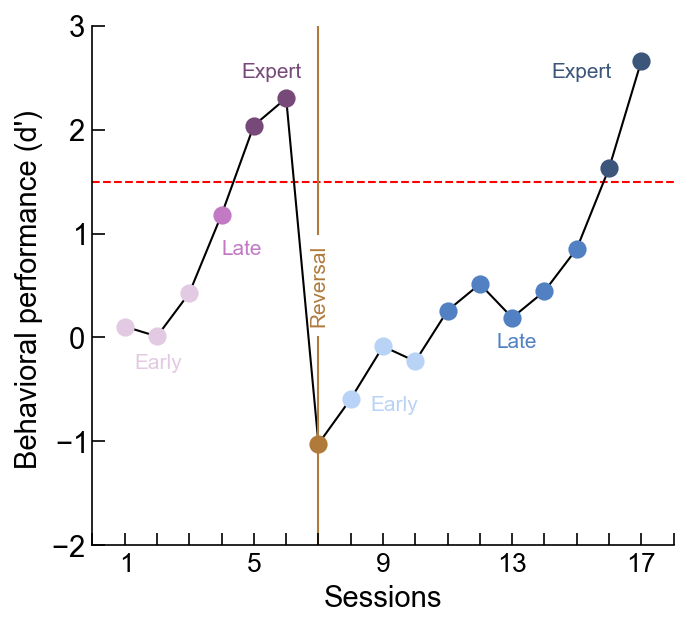

In [6]:
animal_learning_curve_reconstructed(df,'BS_108')